## Import Library

In [ ]:
import os
import time
import copy

import pandas as pd

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet50
import time
from torch.autograd import Variable
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

import seaborn as sns
import numpy as np
from PIL import Image

from torchvision import models

import gc # Garbage Collector untuk membersihkan memori

# Install Gradio untuk deployment nanti
!pip install gradio -q
import gradio as gr

## Step 1: Persiapan Environment & Metadata Dataset

In [ ]:
# 1. Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 2. Setup Path
data_path='drive/MyDrive/indonesia_ai/Project1_ViolaJones/dataset'
attr_file_path = os.path.join(data_path, 'list_attribute.txt')
image_folder_path = os.path.join(data_path, 'Images')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

Menggunakan device: cuda


In [ ]:
# 3. Ekstraksi Metadata
print("\n=== METADATA DATASET ===")
if os.path.exists(image_folder_path):
    images_list = [f for f in os.listdir(image_folder_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
    folder_size_mb = sum(os.path.getsize(os.path.join(image_folder_path, f)) for f in images_list) / (1024 * 1024)
    print(f"Total file gambar : {len(images_list)} files")
    print(f"Ukuran folder     : {folder_size_mb:.2f} MB")

    if len(images_list) > 0:
        with Image.open(os.path.join(image_folder_path, images_list[0])) as img:
            print(f"Resolusi sampel   : {img.size[0]}x{img.size[1]} pixels | Mode: {img.mode}")
else:
    print("Folder Images tidak ditemukan!")


=== METADATA DATASET ===
Total file gambar : 5017 files
Ukuran folder     : 33.27 MB
Resolusi sampel   : 178x218 pixels | Mode: RGB


##Step 2: Preprocessing & Visualisasi EDA

/tmp/ipykernel_5048/2009616268.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(attr_file_path, delim_whitespace=True, skiprows=1)



Menampilkan Sampel Gambar beserta Metadata & Label Dinamis:


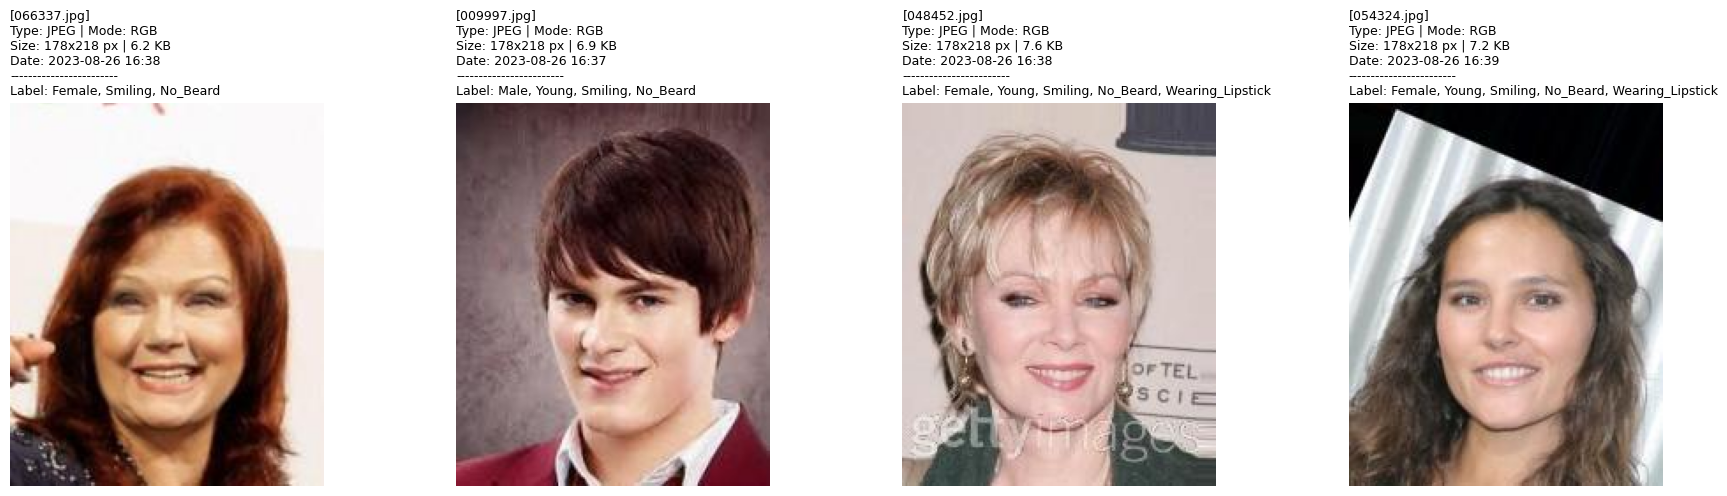

In [ ]:
import datetime # Tambahan library untuk memformat tanggal

# 1. Load Data
df = pd.read_csv(attr_file_path, delim_whitespace=True, skiprows=1)
df.reset_index(inplace=True)
df.rename(columns={'index': 'image_id'}, inplace=True)

# 2. Re-encode -1 menjadi 0
df = df.replace(-1, 0)

# 3. Filtering Ketersediaan Gambar
df['image_exists'] = df['image_id'].apply(lambda x: os.path.exists(os.path.join(image_folder_path, x)))
df_filtered = df[df['image_exists'] == True].copy()

# Pilih Atribut Target
target_attributes = ['Male', 'Young', 'Smiling', 'Eyeglasses', 'No_Beard', 'Wearing_Lipstick']
df_final = df_filtered[['image_id'] + target_attributes]

# 4. Visualisasi Sampel dengan Logika If-Else dan Tampilan Metadata Lengkap
def show_sample_metadata_enhanced(df, img_dir, targets, num_samples=4):
    samples = df.sample(num_samples)
    # Lebarkan figure agar teks metadata yang panjang tidak terpotong
    fig, axes = plt.subplots(1, num_samples, figsize=(18, 5))

    for ax, (_, row) in zip(axes, samples.iterrows()):
        img_name = row['image_id']
        img_path = os.path.join(img_dir, img_name)

        # --- EKSTRAKSI METADATA FILE ---
        file_size_kb = os.path.getsize(img_path) / 1024

        # Mengambil tanggal modifikasi file
        # (Pada dataset standar, EXIF biasanya dihapus, jadi kita pakai tanggal OS)
        mtime = os.path.getmtime(img_path)
        date_str = datetime.datetime.fromtimestamp(mtime).strftime('%Y-%m-%d %H:%M')

        with Image.open(img_path) as img:
            width, height = img.size
            # Ambil format dari PIL, jika kosong ambil dari ekstensi nama file
            img_format = img.format if img.format else img_path.split('.')[-1].upper()
            color_mode = img.mode

            ax.imshow(img)

            # --- LOGIKA IF-ELSE GENDER ---
            active_attrs = []
            for attr in targets:
                val = row[attr]
                if attr == 'Male':
                    active_attrs.append("Male" if val == 1 else "Female")
                elif val == 1:
                    active_attrs.append(attr)

            # --- PENGGABUNGAN TEKS ---
            attr_text = ", ".join(active_attrs)

            # Format string untuk judul di atas setiap gambar
            metadata_text = (
                f"[{img_name}]\n"
                f"Type: {img_format} | Mode: {color_mode}\n"
                f"Size: {width}x{height} px | {file_size_kb:.1f} KB\n"
                f"Date: {date_str}\n"
                f"------------------------\n"
                f"Label: {attr_text}"
            )

            # Set teks dengan tata letak rata kiri (loc='left') agar terlihat rapi seperti daftar
            ax.set_title(metadata_text, fontsize=9, color='black', loc='left')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

print("\nMenampilkan Sampel Gambar beserta Metadata & Label Dinamis:")
show_sample_metadata_enhanced(df_final, image_folder_path, target_attributes)

# 5. Split Dataset
train_data, test_data = train_test_split(df_final, test_size=0.2, random_state=42)

## Step 3: Dataset & Dataloaders

In [ ]:
class MultiLabelFaceDataset(Dataset):
    def __init__(self, dataframe, image_dir, target_cols, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.target_cols = target_cols

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['image_id']
        image = Image.open(os.path.join(self.image_dir, img_name)).convert('RGB')
        labels = torch.tensor(self.dataframe.iloc[idx][self.target_cols].values.astype('float32'))
        if self.transform:
            image = self.transform(image)
        return image, labels

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_set = MultiLabelFaceDataset(train_data, image_folder_path, target_attributes, transform)
test_set = MultiLabelFaceDataset(test_data, image_folder_path, target_attributes, transform)

# Batch size 16 agar memori GPU aman
dataloaders = {
    'train': DataLoader(train_set, batch_size=16, shuffle=True, num_workers=2),
    'test': DataLoader(test_set, batch_size=16, shuffle=False, num_workers=2)
}
dataset_sizes = {'train': len(train_set), 'test': len(test_set)}

## Step 4: Arsitektur Model (5 Algoritma)

In [ ]:
def get_architecture(model_name, num_classes):
    if model_name == 'alexnet':
        model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    elif model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'googlenet':
        model = models.googlenet(weights=models.GoogLeNet_Weights.IMAGENET1K_V1)
        model.aux_logits = False
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'vgg16':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    elif model_name == 'resnext50':
        model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

## Step 5: Mesin Training (OneCycleLR)

In [ ]:
def train_finetune_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=5):
    # 1. Siapkan dictionary untuk merekam 4 metrik
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        print(f"  Epoch {epoch+1}/{num_epochs}", end=" -> ")
        for phase in ['train', 'test']:
            model.train() if phase == 'train' else model.eval()
            running_loss, running_corrects, total_labels = 0.0, 0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        scheduler.step()

                preds = (torch.sigmoid(outputs) > 0.5).float()
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels).item()
                total_labels += inputs.size(0) * len(target_attributes)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / total_labels

            # 2. Simpan metrik ke dalam history sesuai fasenya
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)
                print(f"Val Loss: {epoch_loss:.4f} | Val Acc: {epoch_acc:.4f}")

                # Simpan model terbaik berdasarkan validation loss terendah
                if epoch_loss < best_loss:
                    best_loss, best_model_wts = epoch_loss, copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return model, history # Kembalikan model beserta history lengkap

## Step 6: Eksekusi Eksperimen & Perbandingan

=== MEMULAI BENCHMARKING 5 ARSITEKTUR ===

[ALEXNET] Memulai Training...
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 184MB/s]


  Epoch 1/4 -> Val Loss: 0.3984 | Val Acc: 0.8288
  Epoch 2/4 -> Val Loss: 0.2722 | Val Acc: 0.8810
  Epoch 3/4 -> Val Loss: 0.2104 | Val Acc: 0.9082
  Epoch 4/4 -> Val Loss: 0.1980 | Val Acc: 0.9170
Selesai dalam 3m 1s


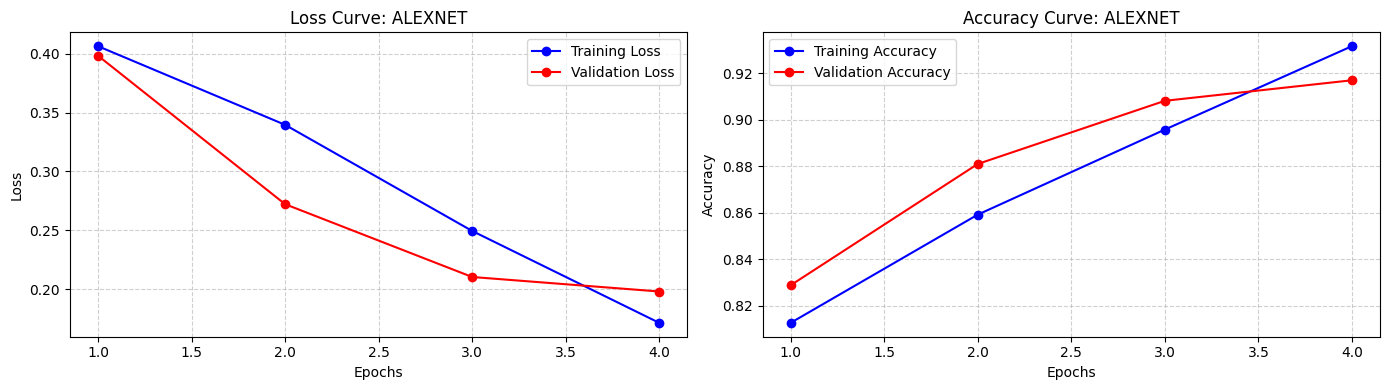


[RESNET50] Memulai Training...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


  Epoch 1/4 -> Val Loss: 0.3088 | Val Acc: 0.8682
  Epoch 2/4 -> Val Loss: 0.2620 | Val Acc: 0.8935
  Epoch 3/4 -> Val Loss: 0.1717 | Val Acc: 0.9323
  Epoch 4/4 -> Val Loss: 0.1523 | Val Acc: 0.9405
Selesai dalam 1m 28s


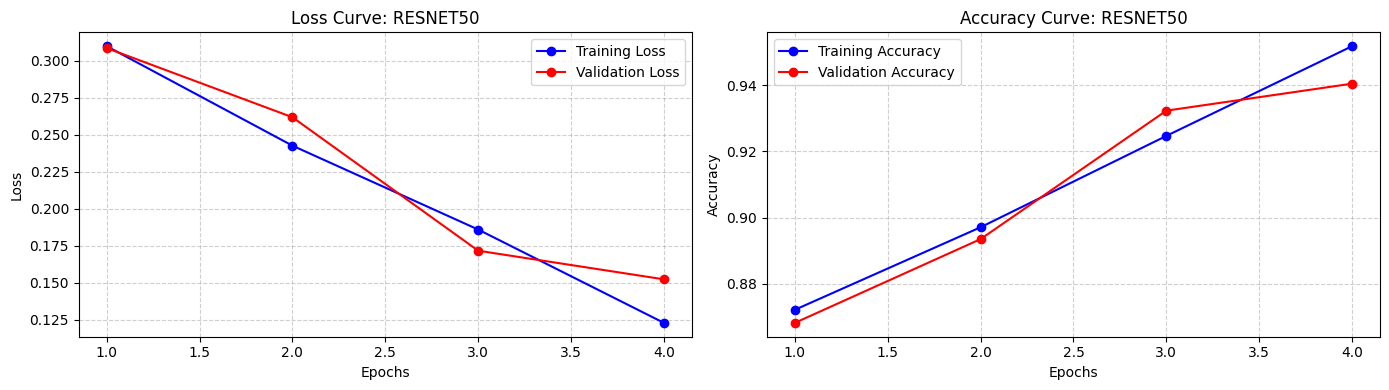


[GOOGLENET] Memulai Training...
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 233MB/s]


  Epoch 1/4 -> Val Loss: 0.3211 | Val Acc: 0.8758
  Epoch 2/4 -> Val Loss: 0.2197 | Val Acc: 0.9057
  Epoch 3/4 -> Val Loss: 0.1621 | Val Acc: 0.9345
  Epoch 4/4 -> Val Loss: 0.1497 | Val Acc: 0.9393
Selesai dalam 0m 58s


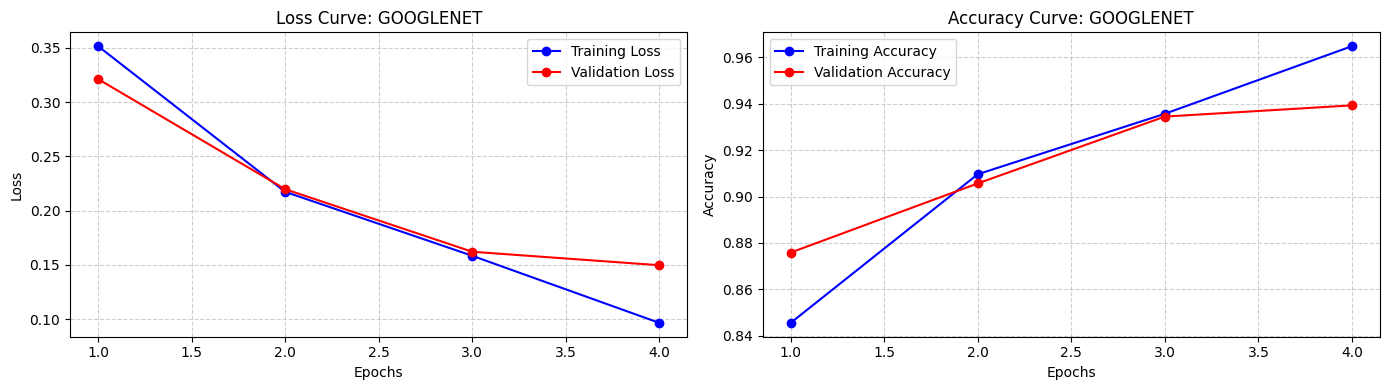


[VGG16] Memulai Training...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 203MB/s]


  Epoch 1/4 -> Val Loss: 0.4988 | Val Acc: 0.7607
  Epoch 2/4 -> Val Loss: 0.5432 | Val Acc: 0.6983
  Epoch 3/4 -> Val Loss: 0.5420 | Val Acc: 0.6983
  Epoch 4/4 -> Val Loss: 0.5421 | Val Acc: 0.6983
Selesai dalam 2m 59s


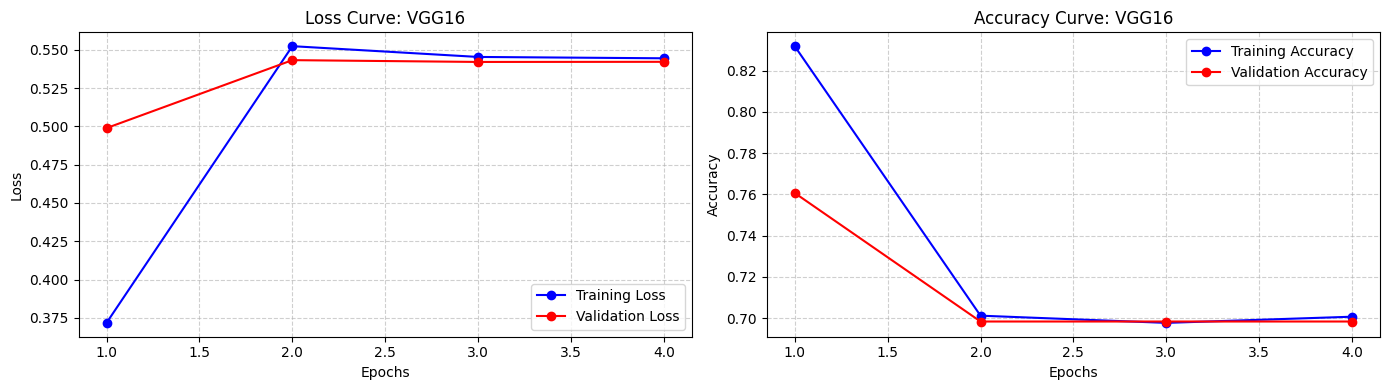


[RESNEXT50] Memulai Training...
Downloading: "https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-7cdf4587.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 224MB/s]


  Epoch 1/4 -> Val Loss: 0.8412 | Val Acc: 0.7072
  Epoch 2/4 -> Val Loss: 0.2264 | Val Acc: 0.9128
  Epoch 3/4 -> Val Loss: 0.1683 | Val Acc: 0.9320
  Epoch 4/4 -> Val Loss: 0.1549 | Val Acc: 0.9372
Selesai dalam 1m 53s


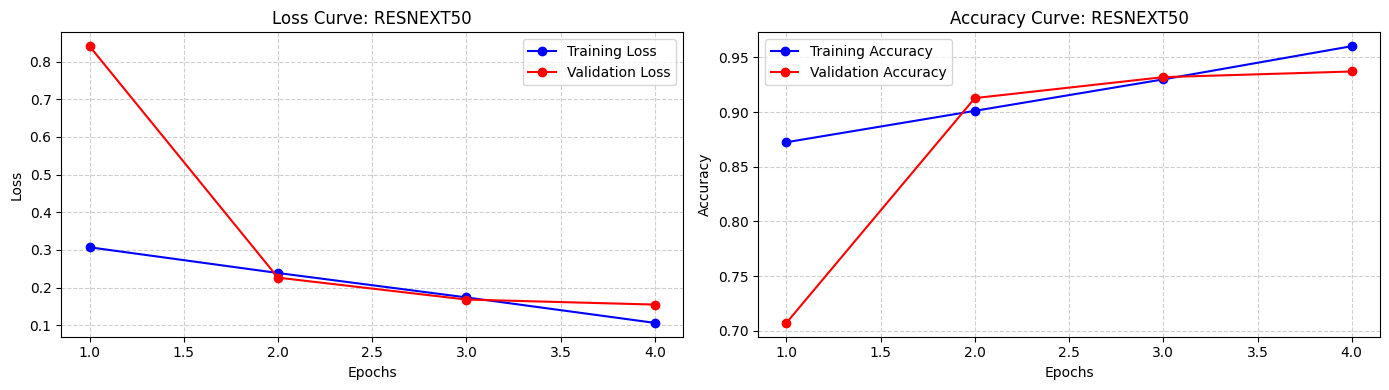


=== KESIMPULAN PERBANDINGAN ===


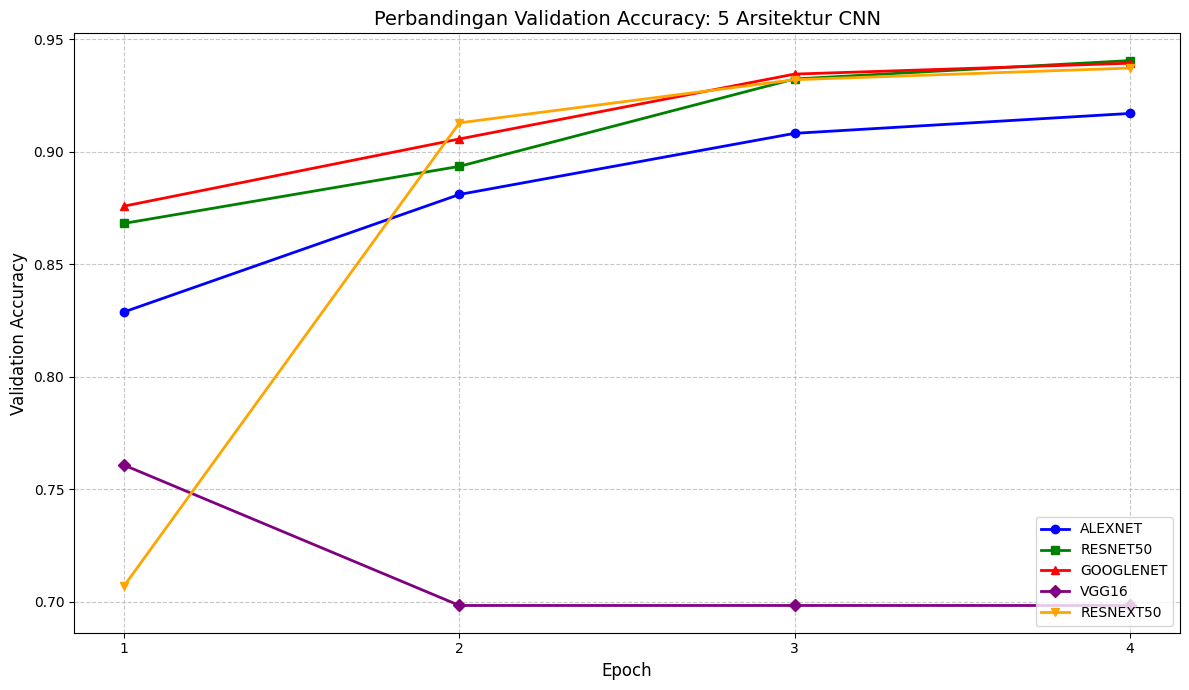


🏅 Model Terbaik: RESNET50 dengan Akurasi: 0.9405


In [ ]:
# 1. Definisi Fungsi Plotting Learning Curves
def plot_learning_curves(history, model_name):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # Grafik Loss
    ax1.plot(epochs, history['train_loss'], 'b-o', label='Training Loss')
    ax1.plot(epochs, history['val_loss'], 'r-o', label='Validation Loss')
    ax1.set_title(f'Loss Curve: {model_name.upper()}')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Grafik Accuracy
    ax2.plot(epochs, history['train_acc'], 'b-o', label='Training Accuracy')
    ax2.plot(epochs, history['val_acc'], 'r-o', label='Validation Accuracy')
    ax2.set_title(f'Accuracy Curve: {model_name.upper()}')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# 2. Setup Parameter Eksperimen
architectures = ['alexnet', 'resnet50', 'googlenet', 'vgg16', 'resnext50']
num_classes = len(target_attributes)
results_history = {} # Untuk menyimpan val_acc akhir untuk grafik gabungan
best_overall_acc, best_overall_model_name, best_overall_model = 0.0, "", None

num_epochs = 4 # Anda bisa menaikkannya ke 10-15

print("=== MEMULAI BENCHMARKING 5 ARSITEKTUR ===")
for arch in architectures:
    print(f"\n[{arch.upper()}] Memulai Training...")
    since = time.time()

    # Inisialisasi arsitektur baru
    model = get_architecture(arch, num_classes)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.001,
                                              steps_per_epoch=len(dataloaders['train']), epochs=num_epochs)

    # Proses Training
    trained_model, history = train_finetune_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs)

    time_elapsed = time.time() - since
    print(f"Selesai dalam {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")

    # 3. Tampilkan Learning Curve khusus untuk arsitektur ini
    plot_learning_curves(history, arch)

    # Simpan riwayat akurasi validasi untuk grafik gabungan di akhir
    results_history[arch] = history['val_acc']

    # Cek apakah ini model terbaik
    max_val_acc = max(history['val_acc'])
    if max_val_acc > best_overall_acc:
        best_overall_acc, best_overall_model_name = max_val_acc, arch
        best_overall_model = copy.deepcopy(trained_model)

    # Bersihkan VRAM GPU sebelum lanjut ke arsitektur berikutnya
    del model, criterion, optimizer, scheduler, trained_model
    torch.cuda.empty_cache()
    gc.collect()

# 4. Visualisasi Gabungan (Perbandingan 5 Arsitektur)
print("\n=== KESIMPULAN PERBANDINGAN ===")
plt.figure(figsize=(12, 7))
plt.title("Perbandingan Validation Accuracy: 5 Arsitektur CNN", fontsize=14)

colors = ['blue', 'green', 'red', 'purple', 'orange']
markers = ['o', 's', '^', 'D', 'v']

for idx, (arch, acc) in enumerate(results_history.items()):
    plt.plot(range(1, num_epochs + 1), acc, marker=markers[idx], color=colors[idx], label=arch.upper(), linewidth=2)

plt.xticks(range(1, num_epochs + 1))
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation Accuracy", fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"\n🏅 Model Terbaik: {best_overall_model_name.upper()} dengan Akurasi: {best_overall_acc:.4f}")

## Step 7: Analisis Confusion Matrix Khusus Gender


=== CONFUSION MATRIX GENDER (RESNET50) ===


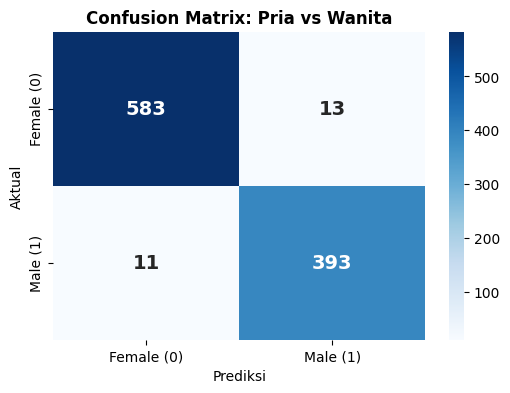

              precision    recall  f1-score   support

      Female       0.98      0.98      0.98       596
        Male       0.97      0.97      0.97       404

    accuracy                           0.98      1000
   macro avg       0.97      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



In [ ]:
def evaluate_gender_cm(model, test_loader):
    print(f"\n=== CONFUSION MATRIX GENDER ({best_overall_model_name.upper()}) ===")
    model.eval()
    all_preds, all_labels = [], []
    gender_idx = target_attributes.index('Male')

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs.to(device))
            probs = torch.sigmoid(outputs)[:, gender_idx]
            preds = (probs > 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels[:, gender_idx].cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Female (0)', 'Male (1)'], yticklabels=['Female (0)', 'Male (1)'],
                annot_kws={"size": 14, "weight": "bold"})
    plt.title('Confusion Matrix: Pria vs Wanita', fontweight='bold')
    plt.ylabel('Aktual'); plt.xlabel('Prediksi'); plt.show()

    print(classification_report(all_labels, all_preds, target_names=['Female', 'Male']))

evaluate_gender_cm(best_overall_model, dataloaders['test'])

##Step 8: Visualisasi Metrik Evaluasi Lengkap (Precision, Recall, F1-Score)


=== EVALUASI METRIK LENGKAP (RESNET50) ===


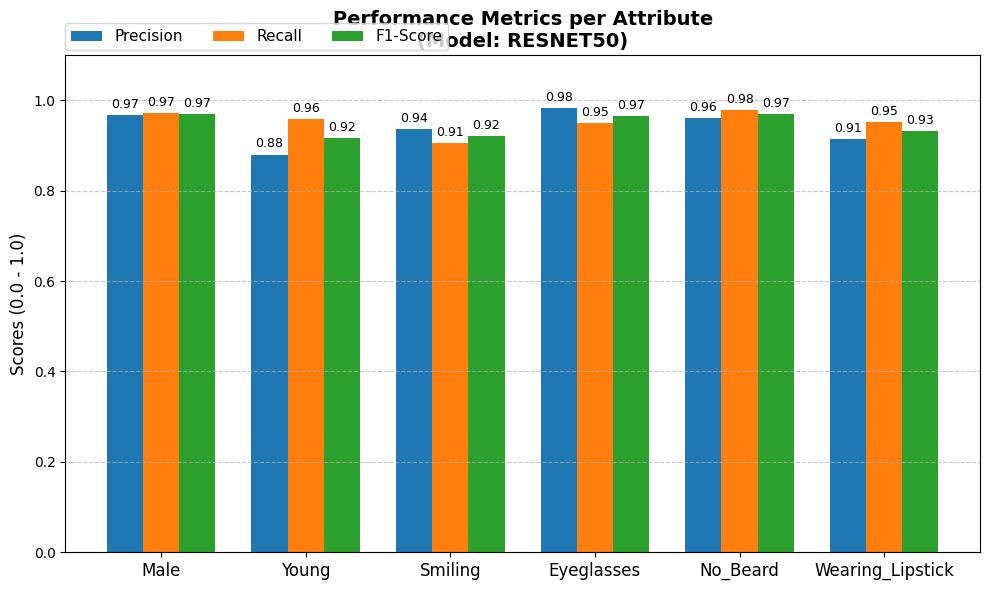

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt

def plot_comprehensive_metrics(model, test_loader, target_names, device):
    print(f"\n=== EVALUASI METRIK LENGKAP ({best_overall_model_name.upper()}) ===")
    model.eval()

    all_preds = []
    all_labels = []

    # 1. Kumpulkan semua prediksi dari Test Set
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            # Ubah output menjadi probabilitas dan threshold di 0.5
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # 2. Hitung Precision, Recall, dan F1-Score untuk setiap atribut
    # Rata-rata 'binary' dihitung independen per kolom (per atribut)
    precisions = []
    recalls = []
    f1_scores = []

    for i in range(len(target_names)):
        # Ambil kolom ke-i untuk label dan prediksi
        col_labels = all_labels[:, i]
        col_preds = all_preds[:, i]

        # Hitung metrik (pos_label=1 karena kita fokus pada deteksi keberadaan atribut)
        p, r, f1, _ = precision_recall_fscore_support(col_labels, col_preds, average='binary', zero_division=0)

        precisions.append(p)
        recalls.append(r)
        f1_scores.append(f1)

    # 3. Visualisasi Grouped Bar Chart
    x = np.arange(len(target_names))  # Lokasi label di sumbu X
    width = 0.25  # Lebar batang

    fig, ax = plt.subplots(figsize=(10, 6))

    # Buat 3 batang (bar) berdampingan untuk setiap atribut
    rects1 = ax.bar(x - width, precisions, width, label='Precision', color='#1f77b4')
    rects2 = ax.bar(x, recalls, width, label='Recall', color='#ff7f0e')
    rects3 = ax.bar(x + width, f1_scores, width, label='F1-Score', color='#2ca02c')

    # Tambahkan teks, label, judul, dll
    ax.set_ylabel('Scores (0.0 - 1.0)', fontsize=12)
    ax.set_title(f'Performance Metrics per Attribute\n(Model: {best_overall_model_name.upper()})', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(target_names, fontsize=12)
    ax.legend(loc='lower left', bbox_to_anchor=(0.0, 1.01), ncol=3, borderaxespad=0, fontsize=11)
    ax.set_ylim(0, 1.1) # Set limit Y agar ada ruang untuk teks di atas bar
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Fungsi untuk menambahkan teks angka di atas setiap bar
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    autolabel(rects1)
    autolabel(rects2)
    autolabel(rects3)

    plt.tight_layout()
    plt.show()

# Jalankan fungsi visualisasi menggunakan model terbaik dan Dataloader testing
plot_comprehensive_metrics(best_overall_model, dataloaders['test'], target_attributes, device)

##Step 9: Ekspor Model (PyTorch & ONNX)

In [ ]:
!pip install onnxscript -q
import torch.onnx
import os

# Pastikan model dalam mode eval
best_overall_model.eval()

model_save_dir = '/content/drive/MyDrive/indonesia_ai/Project1_ViolaJones/dataset/model_saved/'
os.makedirs(model_save_dir, exist_ok=True)

pth_path = os.path.join(model_save_dir, f'best_{best_overall_model_name}.pth')
onnx_path = os.path.join(model_save_dir, f'best_{best_overall_model_name}.onnx')

# Simpan .pth
torch.save(best_overall_model.state_dict(), pth_path)
print(f"Tersimpan (PyTorch) : {pth_path}")

# Ekspor .onnx
dummy_input = torch.randn(1, 3, 224, 224, device=device)
torch.onnx.export(best_overall_model,
                  dummy_input,
                  onnx_path,
                  export_params=True,
                  opset_version=11,
                  input_names=['input'],
                  output_names=['output'],
                  dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}})
print(f"Diekspor (ONNX)     : {onnx_path}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 20.5 MB/s eta 0:00:00
Tersimpan (PyTorch) : /content/drive/MyDrive/indonesia_ai/Project1_ViolaJones/dataset/model_saved/best_resnet50.pth


/tmp/ipykernel_5048/2473202168.py:20: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(best_overall_model,
W0313 14:42:07.216000 5048 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0313 14:42:08.287000 5048 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_r

[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

[torch.onnx] Translate the graph into ONNX... ✅
Applied 107 of general pattern rewrite rules.
Diekspor (ONNX)     : /content/drive/MyDrive/indonesia_ai/Project1_ViolaJones/dataset/model_saved/best_resnet50.onnx


##Step 10: Web UI Deployment (Gradio) dengan If-Else Gender

In [ ]:
def predict_face_attributes(image):
    if image is None: return {}
    img_tensor = transform(Image.fromarray(image).convert('RGB')).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = torch.sigmoid(best_overall_model(img_tensor))[0].cpu().numpy()

    result_dict = {}
    for i, attr in enumerate(target_attributes):
        prob = float(probs[i])
        if attr == 'Male':
            if prob > 0.5: result_dict['Gender: Male'] = prob
            else: result_dict['Gender: Female'] = 1.0 - prob
        else:
            result_dict[attr] = prob
    return result_dict

interface = gr.Interface(
    fn=predict_face_attributes,
    inputs=gr.Image(type="numpy", label="Upload Foto Wajah"),
    outputs=gr.Label(num_top_classes=len(target_attributes), label="Hasil Prediksi"),
    title="🚀 AI Face & Gender Analyzer",
    description=f"Ditenagai oleh **{best_overall_model_name.upper()}**. Mendeteksi gender secara presisi beserta atribut wajah lainnya.",
    theme="default"
)
interface.launch(inline=True, share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3423a94d99df79e1b6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
